<a href="https://colab.research.google.com/github/aryanrzn/Machin-Learning/blob/main/Appliances_Energy_M2M_Aryan_Rezanezhad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup + Load

Imports & plotting setup


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is used later for interactive plots (optional)
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.cluster import DBSCAN
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(23)


Get the dataset

In [2]:
import os
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
csv_name = "energydata_complete.csv"

if not os.path.exists(csv_name):
    urllib.request.urlretrieve(url, csv_name)
    print("Downloaded:", csv_name)
else:
    print("File already exists:", csv_name)

Downloaded: energydata_complete.csv


Load CSV into a DataFrame

In [3]:
df = pd.read_csv("energydata_complete.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


View columns cleanly

In [4]:
pd.set_option("display.max_columns", None)
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


Missing values check

In [5]:
df.isna().sum().sort_values(ascending=False)

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


Quick descriptive stats for numeric columns (mean/std/min/max)

In [6]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,19.592106,50.949283,7.910939,54.609083,20.267106,35.388200,22.029107,42.936165,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,1.844623,9.022034,6.090347,31.149806,2.109993,5.114208,1.956162,5.224361,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,15.330000,29.815000,-6.065000,1.000000,15.390000,23.200000,16.306667,29.600000,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,18.277500,45.400000,3.626667,30.025000,18.700000,31.500000,20.790000,39.066667,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,19.390000,49.090000,7.300000,55.290000,20.033333,34.863333,22.100000,42.375000,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,20.619643,53.663333,11.256000,83.226667,21.600000,39.000000,23.390000,46.536000,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,25.795000,96.321667,28.290000,99.900000,26.000000,51.400000,27.230000,58.780000,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


# Time features + EDA

Convert date to datetime and derive month/weekday/hour/week and day name. These can capture usage patterns.

In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday
df["hour"] = df["date"].dt.hour
df["week"] = df["date"].dt.isocalendar().week.astype(int)

# Two common forms:
df["day_of_week"] = df["date"].dt.day_name()      # e.g., Monday
df["day_idx"] = df["date"].dt.weekday             # 0..6

df["week_of_month"] = (df["date"].dt.day - 1) // 7 + 1

df[["date", "Appliances", "month", "hour", "day_of_week"]].head()

,date,Appliances,month,hour,day_of_week
0,2016-01-11 17:00:00,60,1,17,Monday
1,2016-01-11 17:10:00,60,1,17,Monday
2,2016-01-11 17:20:00,50,1,17,Monday
3,2016-01-11 17:30:00,50,1,17,Monday
4,2016-01-11 17:40:00,60,1,17,Monday


Feature vs target (scatter)

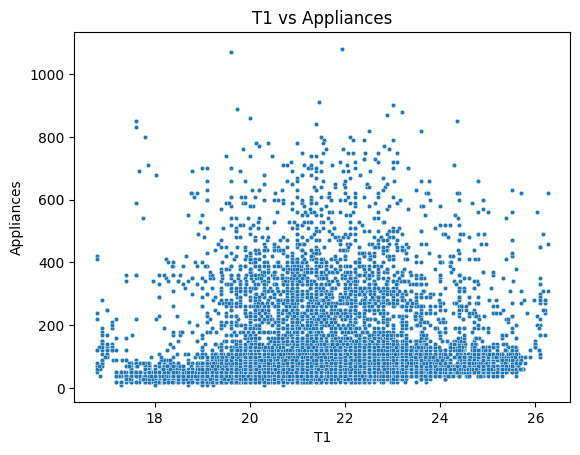

In [8]:
sns.scatterplot(x="T1", y="Appliances", data=df, s=10)
plt.title("T1 vs Appliances")
plt.show()

Compute correlations for numeric columns and visualize them.

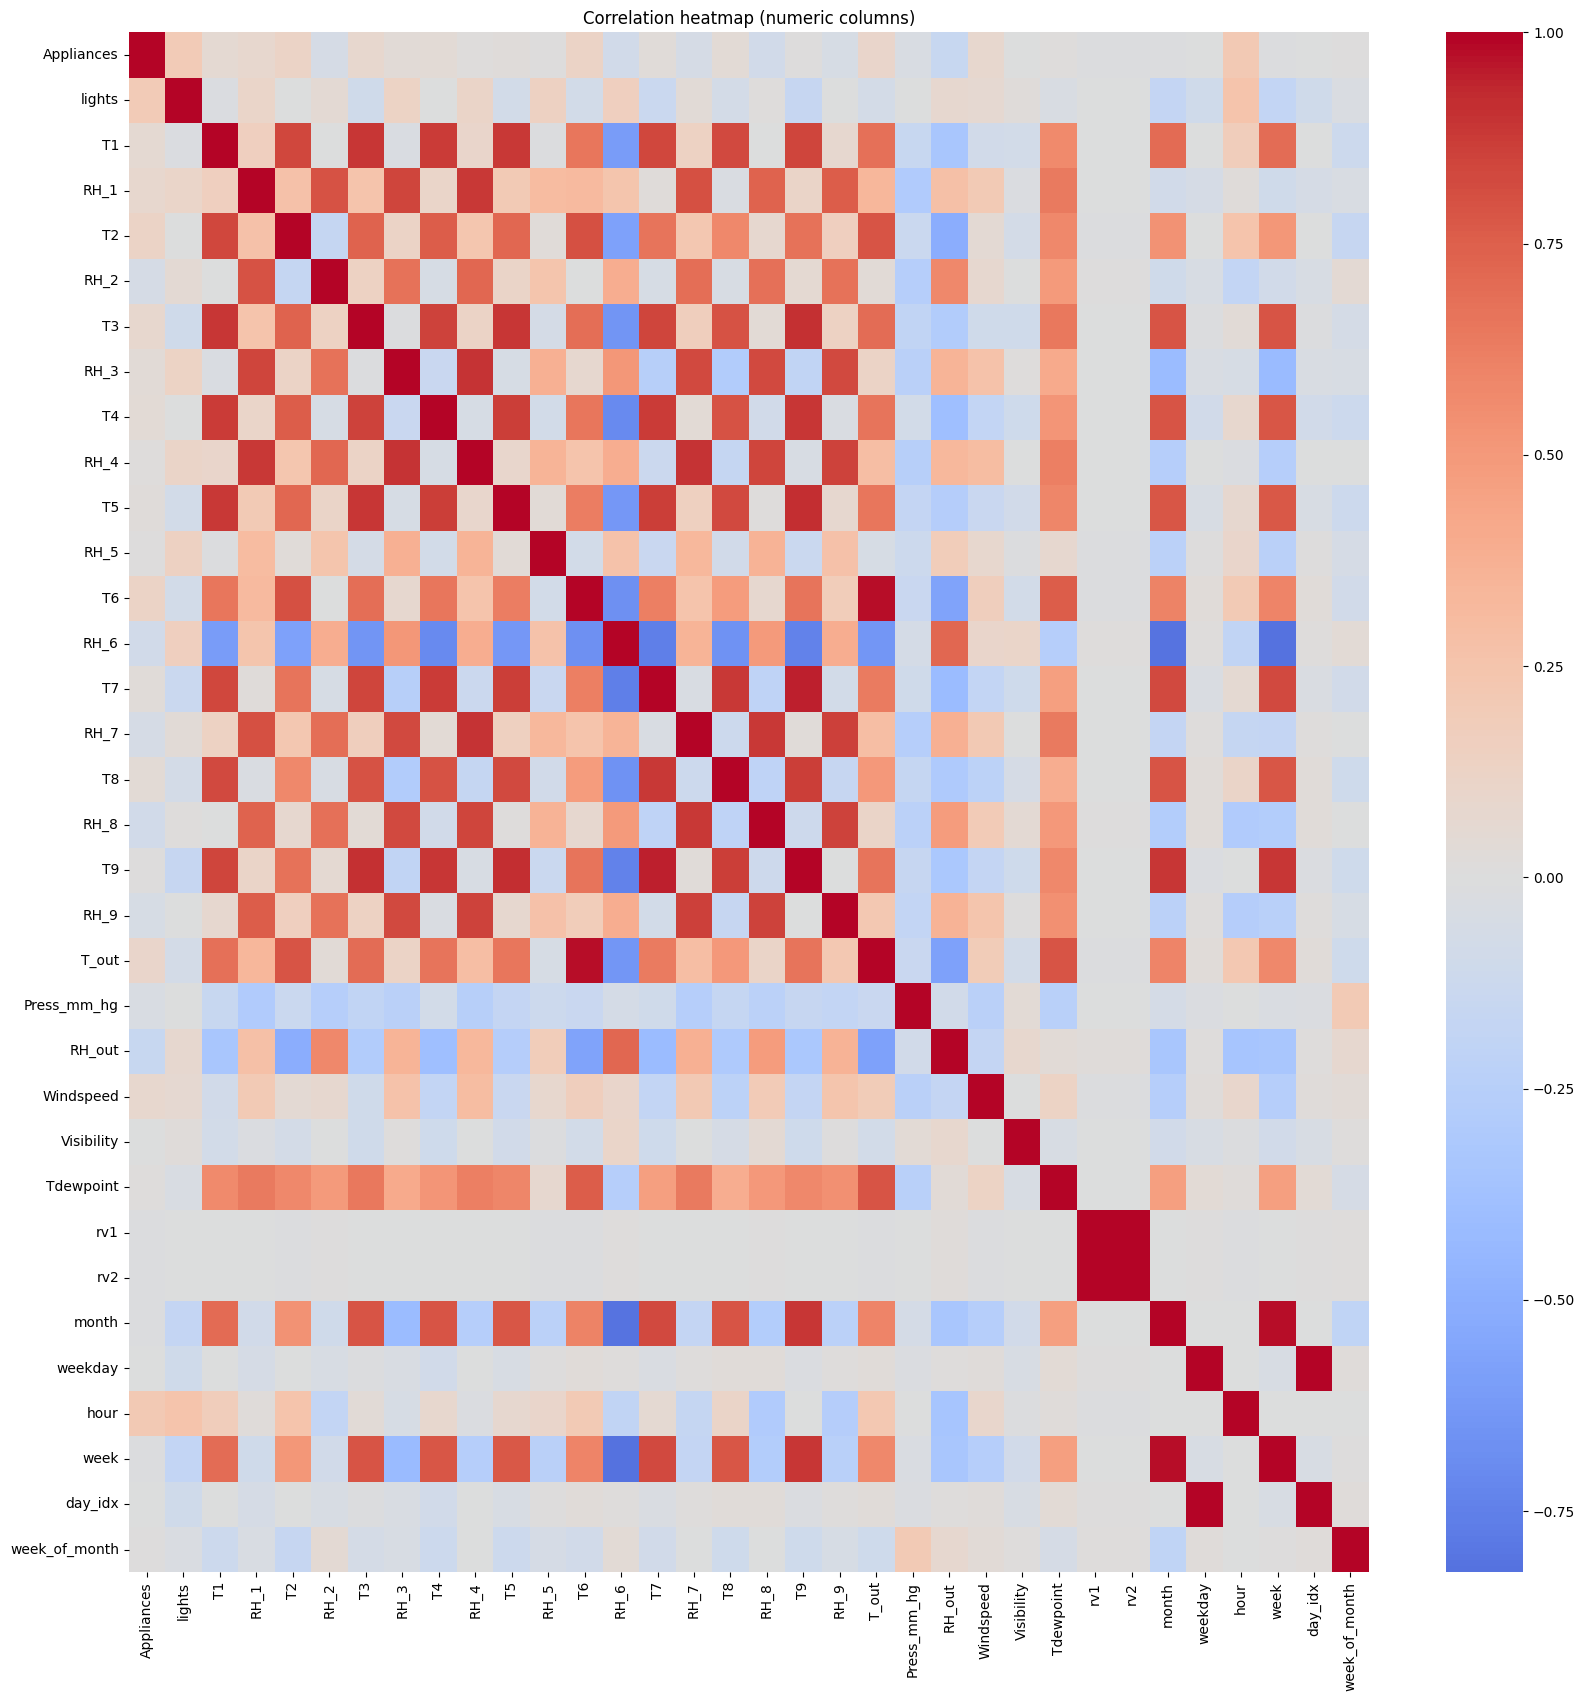

In [9]:
num = df.select_dtypes(include="number")
corr = num.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation heatmap (numeric columns)")
plt.show()

Target distribution

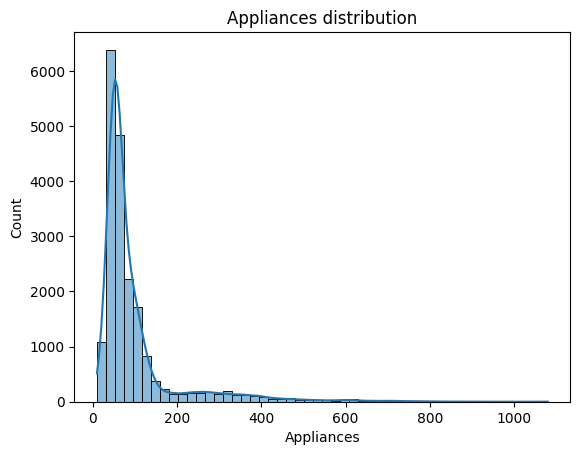

In [10]:
sns.histplot(df["Appliances"], kde=True, bins=50)
plt.title("Appliances distribution")
plt.show()

Multicollinearity check with VIF

High VIF suggests strong multicollinearity; ridge regression usually handles this better.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = [
    "Appliances","lights","T1","RH_1","T2","RH_2","T3","RH_3","T4","RH_4","T5","RH_5",
    "T6","RH_6","T7","RH_7","T8","RH_8","T9","RH_9","T_out","Press_mm_hg",
    "RH_out","Windspeed","Visibility","Tdewpoint"
]

tmp = df[cols].dropna()
vif = pd.DataFrame({
    "col": tmp.columns,
    "vif": [variance_inflation_factor(tmp.values, i) for i in range(tmp.shape[1])]
}).sort_values("vif", ascending=False)

vif

,col,vif
2,T1,3606.384646
18,T9,2605.026073
4,T2,2519.584504
5,RH_2,2205.364940
21,Press_mm_hg,2088.596143
3,RH_1,1688.811559
14,T7,1614.414817
7,RH_3,1572.250962
9,RH_4,1394.032518
22,RH_out,1299.243530


Quick preview

In [12]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,month,weekday,hour,week,day_of_week,day_idx,week_of_month
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,1,0,17,2,Monday,0,2
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,1,0,17,2,Monday,0,2
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,1,0,17,2,Monday,0,2
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,1,0,17,2,Monday,0,2
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,1,0,17,2,Monday,0,2


List columns to confirm feature names for later drops/selection.

In [13]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'month', 'weekday', 'hour',
       'week', 'day_of_week', 'day_idx', 'week_of_month'],
      dtype='object')

# Outliers (DBSCAN + IQR) and encoding

Define a small function that returns DBSCAN cluster labels for a 1D numeric series. (flag outliers where label == -1)

In [14]:
def dbscan_labels(series, eps=0.5, min_samples=10):
    y = np.asarray(series).reshape(-1, 1)
    model = DBSCAN(eps=eps, min_samples=min_samples)
    return model.fit_predict(y)

Run DBSCAN on Appliances (Cluster Appliances values and count labels.)

In [15]:
lab = dbscan_labels(df["Appliances"], eps=0.5, min_samples=10)
pd.Series(lab).value_counts().sort_values(ascending=False)

,count
1,4368
0,3282
17,2019
2,1560
9,1205
...,...
4,11
58,11
59,11
42,10


Outlier indices (DBSCAN)
Find row indices where DBSCAN labeled the point as an outlier (-1)

In [16]:
lab_s = pd.Series(lab, name="cluster")
out_idx = lab_s.index[lab_s == -1]
out_idx

Index([  393,   431,   432,   443,   731,   732,   867,   868,  1031,  1079,
       ...
       15799, 15812, 15841, 16647, 17861, 18820, 18830, 19541, 19581, 19582],
      dtype='int64', length=120)

Add DBSCAN labels as a new column in df.

In [17]:
df["cluster"] = lab
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,month,weekday,hour,week,day_of_week,day_idx,week_of_month,cluster
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,1,0,17,2,Monday,0,2,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,1,0,17,2,Monday,0,2,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,1,0,17,2,Monday,0,2,1
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,1,0,17,2,Monday,0,2,1
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,1,0,17,2,Monday,0,2,0


Outlier count + unique clusters

In [18]:
print("outliers:", (df["cluster"] == -1).sum())
print("unique labels:", sorted(pd.Series(df["cluster"]).unique()))

outliers: 120
unique labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61)]


Scatter plot colored by DBSCAN cluster label.

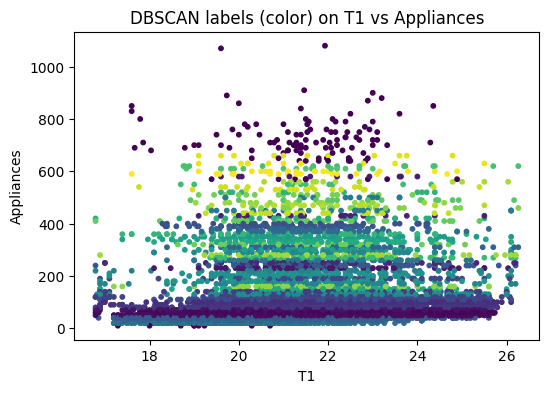

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(df["T1"], df["Appliances"], c=df["cluster"], s=10)
plt.xlabel("T1")
plt.ylabel("Appliances")
plt.title("DBSCAN labels (color) on T1 vs Appliances")
plt.show()

One-hot encode day_of_week (categorical)

Convert day_of_week text into numeric dummy variables and build 'data' used later.

In [20]:
data = pd.get_dummies(df, columns=["day_of_week"], drop_first=False)
data.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,month,weekday,hour,week,day_idx,week_of_month,cluster,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,1,0,17,2,0,2,0,False,True,False,False,False,False,False
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,1,0,17,2,0,2,0,False,True,False,False,False,False,False
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,1,0,17,2,0,2,1,False,True,False,False,False,False,False
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,1,0,17,2,0,2,1,False,True,False,False,False,False,False
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,1,0,17,2,0,2,0,False,True,False,False,False,False,False


Create a binary outlier flag from DBSCAN cluster label and plot it.

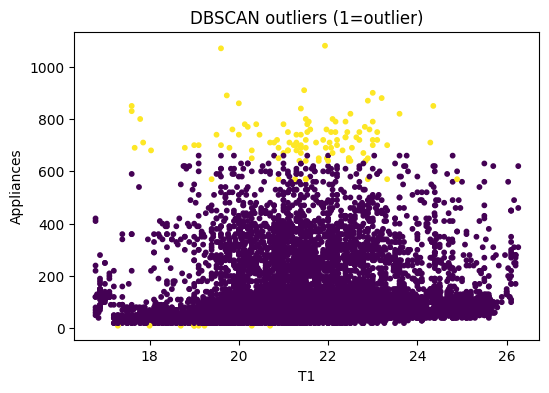

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,month,weekday,hour,week,day_idx,week_of_month,cluster,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,outlier_flag
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,1,0,17,2,0,2,1,False,True,False,False,False,False,False,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,1,0,17,2,0,2,1,False,True,False,False,False,False,False,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0


In [21]:
data["outlier_flag"] = (data["cluster"] == -1).astype(int)

plt.figure(figsize=(6, 4))
plt.scatter(data["T1"], data["Appliances"], c=data["outlier_flag"], s=10)
plt.xlabel("T1")
plt.ylabel("Appliances")
plt.title("DBSCAN outliers (1=outlier)")
plt.show()

data.head()

Create two DataFrames: one without outliers and one containing only outliers.

In [22]:
data_clean = data[data["outlier_flag"] == 0].copy()
data_out = data[data["outlier_flag"] == 1].copy()

print("clean:", data_clean.shape, "outliers:", data_out.shape)
data_clean.head()

clean: (19615, 44) outliers: (120, 44)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,month,weekday,hour,week,day_idx,week_of_month,cluster,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,outlier_flag
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,1,0,17,2,0,2,1,False,True,False,False,False,False,False,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,1,0,17,2,0,2,1,False,True,False,False,False,False,False,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,1,0,17,2,0,2,0,False,True,False,False,False,False,False,0


Plot Appliances vs T1 with outliers colored, plus a boxplot to compare distributions.

In [24]:
fig = px.scatter(
    data,
    x="T1",
    y="Appliances",
    color="outlier_flag",
    marginal_y="violin",
    marginal_x="box",
    trendline="ols",
    template="simple_white",)
fig.show()

fig2 = px.box(data, x="outlier_flag", y="Appliances", points="outliers")
fig2.show()

Outliers via IQR (alternative method)

IQR removed: 2138


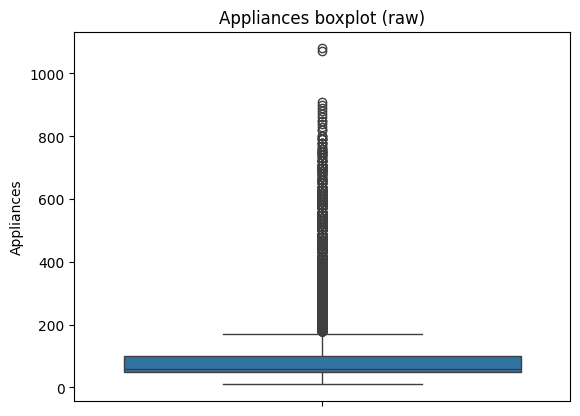

In [25]:
def iqr_filter(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return series[(series >= low) & (series <= high)]

ap_clean_iqr = iqr_filter(df["Appliances"])
ap_clean_iqr = ap_clean_iqr.to_frame("Appliances")

# Indices removed by IQR
iqr_removed_idx = df.index.difference(ap_clean_iqr.index)
print("IQR removed:", len(iqr_removed_idx))

sns.boxplot(y=df["Appliances"])
plt.title("Appliances boxplot (raw)")
plt.show()

Show IQR-cleaned Appliances

In [26]:
ap_clean_iqr.head()

,Appliances
0,60
1,60
2,50
3,50
4,60


Pairplot of selected variables


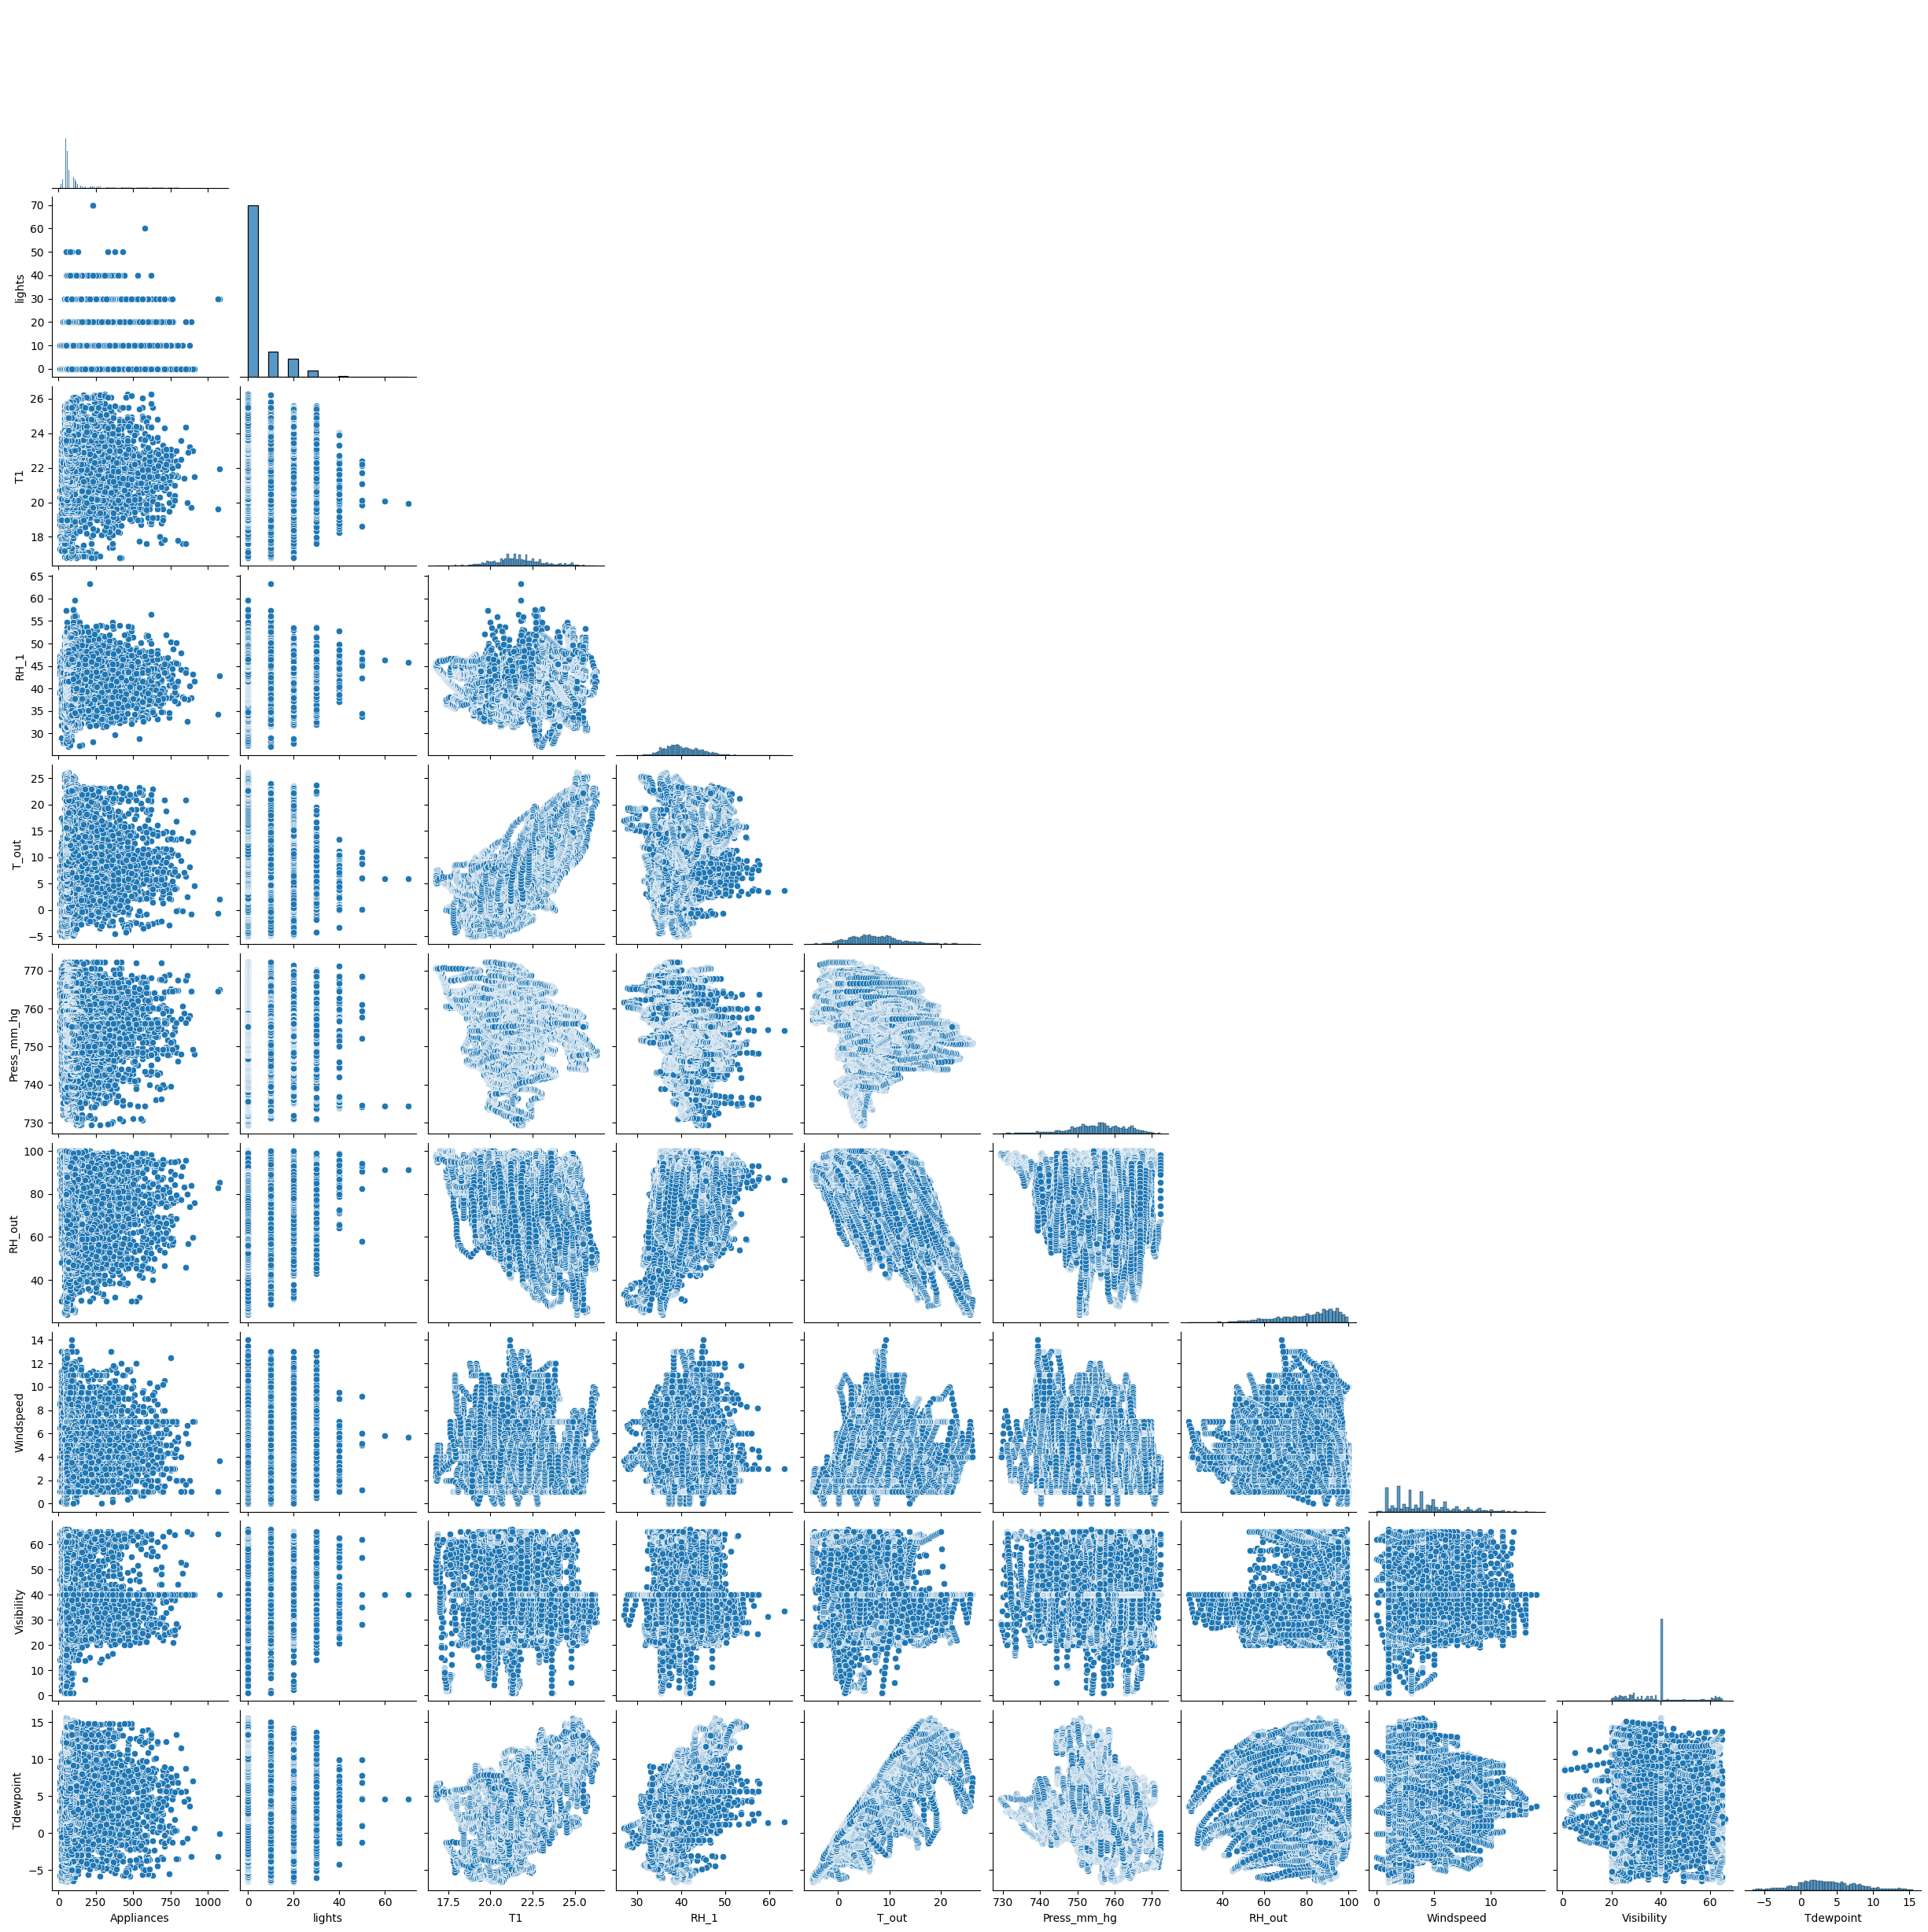

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'month', 'weekday', 'hour',
       'week', 'day_idx', 'week_of_month', 'cluster', 'day_of_week_Friday',
       'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
       'outlier_flag'],
      dtype='object')

In [27]:
small = data[["Appliances","lights","T1","RH_1","T_out","Press_mm_hg","RH_out","Windspeed","Visibility","Tdewpoint"]].copy()
sns.pairplot(small, kind="scatter", corner=True)
plt.show()

data.columns

# Splits + feature selection + scaling

Decision Tree feature importance

In [28]:
X_tmp = data.drop(columns=["Appliances","date","cluster","outlier_flag"], errors="ignore")
y_tmp = data["Appliances"]

X_tr0, X_tmp0, y_tr0, y_tmp0 = train_test_split(X_tmp, y_tmp, test_size=0.4, random_state=23)

tree = DecisionTreeRegressor(random_state=23)
tree.fit(X_tr0, y_tr0)

imp = pd.Series(tree.feature_importances_, index=X_tmp.columns).sort_values(ascending=False)
imp.head(20)

,0
hour,0.147516
T3,0.058201
T8,0.049446
RH_2,0.046959
RH_5,0.044550
RH_3,0.043301
Press_mm_hg,0.042790
RH_1,0.041410
RH_6,0.039860
RH_7,0.038916


Train/Val/Test split (60/20/20)

In [29]:
X = data.drop(columns=["Appliances","date"], errors="ignore")
y = data["Appliances"]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=23)
X_test, X_val, y_test, y_val = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=23)

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

train: (11841, 42) val: (3947, 42) test: (3947, 42)


Feature selection via RFE

In [30]:
# Bin target into 3 classes so LogisticRegression can run
y_bin = pd.qcut(y_train, q=3, labels=False, duplicates="drop")

clf = LogisticRegression(max_iter=500, solver="lbfgs", multi_class="auto")
rfe = RFE(estimator=clf, n_features_to_select=20, step=1)

rfe.fit(X_train, y_bin)
sel_cols = X_train.columns[rfe.support_]
sel_cols

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid

Index(['T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T5', 'T7', 'T8', 'RH_8',
       'T9', 'Tdewpoint', 'month', 'cluster', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Tuesday',
       'day_of_week_Wednesday', 'outlier_flag'],
      dtype='object')

Outlier detection using Local Outlier Factor (LOF) on input features

In [31]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
lab_lof = lof.fit_predict(X_train)

# -1 => outlier
out_flag = (lab_lof == -1).astype(int)

outlier_df = X_train.copy()
outlier_df["outlier"] = out_flag
outlier_df["Appliances"] = y_train.values

outlier_df["outlier"].value_counts()

,count
outlier,
0,11485
1,356


Appliances distribution (LOF table)

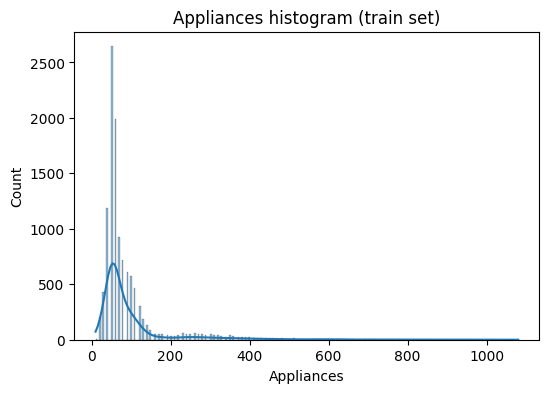

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=outlier_df, x="Appliances", kde=True, ax=ax)
ax.set_title("Appliances histogram (train set)")
plt.show()

Skewness of Appliances

In [33]:
sk = outlier_df["Appliances"].skew()
print(f"Skewness (Appliances) = {sk:.3f}")

Skewness (Appliances) = 3.418


Appliances by LOF outlier flag

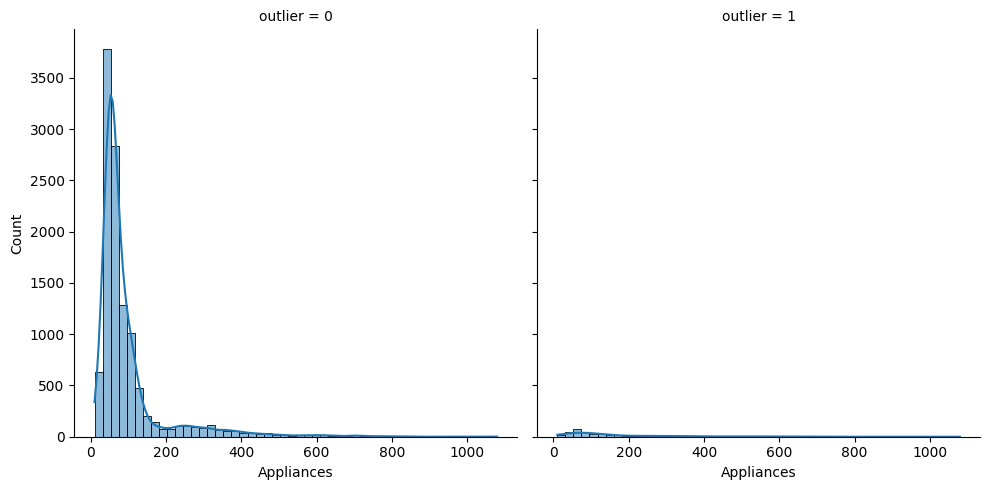

In [34]:
sns.displot(outlier_df, x="Appliances", col="outlier", bins=50, kde=True)
plt.show()

Log transform (log1p) skewness check

In [35]:
ap_log = np.log1p(outlier_df["Appliances"])
print("Skewness (log1p(Appliances)) =", round(ap_log.skew(), 3))

Skewness (log1p(Appliances)) = 1.185


Distribution of log1p(Appliances)

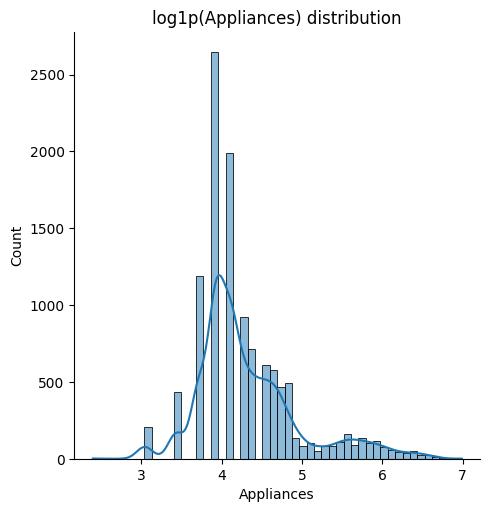

In [36]:
sns.displot(ap_log, bins=50, kde=True)
plt.title("log1p(Appliances) distribution")
plt.show()

Creates scaled arrays X_train_s, X_val_s, X_test_s.

In [37]:
sc = StandardScaler()

X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
X_val_s   = sc.transform(X_val)

y_train_log = np.log1p(y_train)

print("Scaled shapes:", X_train_s.shape, X_val_s.shape, X_test_s.shape)

Scaled shapes: (11841, 42) (3947, 42) (3947, 42)


# Linear / Ridge / Lasso via GD vs SGD

Define small, readable functions to train Linear/Ridge/Lasso using (batch) GD and mini-batch SGD.

In [41]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

def fit_gd(X, y, lr=1e-3, iters=500, lam=0.0, reg="none"):
    """Batch gradient descent for squared error.
    reg: 'none' | 'ridge' | 'lasso'
    lam: regularization strength (skip bias term)
    """
    Xb = add_bias(X)
    w = np.zeros(Xb.shape[1])

    for _ in range(iters):
        pred = Xb @ w
        err = pred - y
        grad = (Xb.T @ err) / len(y)

        if reg == "ridge":
            grad[1:] += lam * w[1:]
        elif reg == "lasso":
            grad[1:] += lam * np.sign(w[1:])

        w -= lr * grad
    return w

def fit_sgd(X, y, lr=1e-3, iters=500, lam=0.0, reg="none", batch=128):
    """Mini-batch SGD for squared error."""
    Xb = add_bias(X)
    w = np.zeros(Xb.shape[1])
    n = len(y)

    for _ in range(iters):
        idx = np.random.choice(n, size=min(batch, n), replace=False)
        Xs = Xb[idx]
        ys = y[idx]

        pred = Xs @ w
        err = pred - ys
        grad = (Xs.T @ err) / len(ys)

        if reg == "ridge":
            grad[1:] += lam * w[1:]
        elif reg == "lasso":
            grad[1:] += lam * np.sign(w[1:])

        w -= lr * grad
    return w

def predict(X, w):
    return add_bias(X) @ w

# containers for results
res_lr = []
res_ridge = []
res_lasso = []

Linear Regression (GD) run 1

In [43]:
w = fit_gd(X_train_s, y_train.values, lr=1e-4, iters=500, lam=1e-3, reg="none")
pred = predict(X_test_s, w)

res_lr.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lr[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 137.24228082991863,
 'r2': -0.7374348833748203}

Linear Regression (GD) run 2

In [44]:
w = fit_gd(X_train_s, y_train.values, lr=1e-3, iters=500, lam=1e-2, reg="none")
pred = predict(X_test_s, w)

res_lr.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lr[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 101.634658963895,
 'r2': 0.04716796227482123}

Linear Regression (GD) run 3

In [45]:
w = fit_gd(X_train_s, y_train.values, lr=1e-2, iters=500, lam=1e-1, reg="none")
pred = predict(X_test_s, w)

res_lr.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lr[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 68.64479699664847,
 'r2': 0.5653417442407387}

Linear Regression metrics table (GD vs SGD)

In [46]:
# SGD runs (same lr/lam grid)
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_s, y_train.values, lr=lr, iters=500, lam=lam, reg="none", batch=256)
    pred = predict(X_test_s, w)
    res_lr.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})

lr_tbl = pd.DataFrame(res_lr).sort_values(["approach","rmse"])
lr_tbl

,approach,lr,lam,rmse,r2
3,GD,0.0100,0.100,68.644797,0.565342
2,GD,0.0010,0.010,101.634659,0.047168
0,GD,0.0001,0.001,137.242281,-0.737435
1,GD,0.0001,0.001,137.242281,-0.737435
6,SGD,0.0100,0.100,68.616699,0.565697
5,SGD,0.0010,0.010,101.486940,0.049936
4,SGD,0.0001,0.001,137.199990,-0.736364


Display a small slice of the scaled training matrix.

In [47]:
X_train_s[:5, :5]

array([[-0.47995445,  0.32725972, -0.76573124,  0.84977079, -1.21021958],
       [-0.47995445,  1.77207107, -0.45246966,  1.41426889, -0.78276126],
       [ 0.7671688 , -0.49565457, -1.52941219, -0.30691197, -1.4281492 ],
       [-0.47995445,  2.19085697,  2.17977433,  3.80300336, -0.45249   ],
       [-0.47995445,  0.38379582, -1.30166255, -0.3192171 , -0.89889156]])

Ridge Regression setup

We reuse the same GD/SGD helpers, but with reg='ridge' to add L2 penalty.

In [48]:
res_ridge = []

Ridge Regression (GD) run 1

In [49]:
w = fit_gd(X_train_s, y_train.values, lr=1e-4, iters=60, lam=1e-3, reg="ridge")
pred = predict(X_test_s, w)
res_ridge.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_ridge[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 142.27623160186124,
 'r2': -0.867228168094446}

Ridge Regression (GD) run 2

In [50]:
w = fit_gd(X_train_s, y_train.values, lr=1e-3, iters=60, lam=1e-2, reg="ridge")
pred = predict(X_test_s, w)
res_ridge.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_ridge[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 136.14869535212418,
 'r2': -0.7098564499346098}

Ridge Regression (GD) run 3

In [51]:
w = fit_gd(X_train_s, y_train.values, lr=1e-2, iters=60, lam=1e-1, reg="ridge")
pred = predict(X_test_s, w)
res_ridge.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_ridge[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 96.80382367127173,
 'r2': 0.13559413146161203}

Ridge metrics table (GD vs SGD)

In [52]:
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_s, y_train.values, lr=lr, iters=60, lam=lam, reg="ridge", batch=256)
    pred = predict(X_test_s, w)
    res_ridge.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})

ridge_tbl = pd.DataFrame(res_ridge).sort_values(["approach","rmse"])
ridge_tbl

,approach,lr,lam,rmse,r2
2,GD,0.0100,0.100,96.803824,0.135594
1,GD,0.0010,0.010,136.148695,-0.709856
0,GD,0.0001,0.001,142.276232,-0.867228
5,SGD,0.0100,0.100,97.166595,0.129103
4,SGD,0.0010,0.010,136.005559,-0.706263
3,SGD,0.0001,0.001,142.278193,-0.867280


Lasso Regression setup

Lasso uses L1 penalty. We use a subgradient (sign) for the L1 term.

In [53]:
res_lasso = []

Lasso Regression (GD) run 1

In [54]:
w = fit_gd(X_train_s, y_train.values, lr=1e-4, iters=100, lam=1e-3, reg="lasso")
pred = predict(X_test_s, w)
res_lasso.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lasso[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 141.8015826286466,
 'r2': -0.8547903973856876}

Lasso Regression (GD) run 2

In [55]:
w = fit_gd(X_train_s, y_train.values, lr=1e-3, iters=100, lam=1e-2, reg="lasso")
pred = predict(X_test_s, w)
res_lasso.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lasso[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 131.96006106965777,
 'r2': -0.6062668575767607}

Lasso Regression (GD) run 3

In [56]:
w = fit_gd(X_train_s, y_train.values, lr=1e-2, iters=100, lam=1e-1, reg="lasso")
pred = predict(X_test_s, w)
res_lasso.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})
res_lasso[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 82.56480689907734,
 'r2': 0.37118539253009986}

Lasso metrics table (GD vs SGD)

In [57]:
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_s, y_train.values, lr=lr, iters=100, lam=lam, reg="lasso", batch=256)
    pred = predict(X_test_s, w)
    res_lasso.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test, pred), "r2":r2_score(y_test, pred)})

lasso_tbl = pd.DataFrame(res_lasso).sort_values(["approach","rmse"])
lasso_tbl

,approach,lr,lam,rmse,r2
2,GD,0.0100,0.100,82.564807,0.371185
1,GD,0.0010,0.010,131.960061,-0.606267
0,GD,0.0001,0.001,141.801583,-0.854790
5,SGD,0.0100,0.100,83.192083,0.361594
4,SGD,0.0010,0.010,131.866380,-0.603987
3,SGD,0.0001,0.001,141.783224,-0.854310


Combined comparison table (Linear/Ridge/Lasso)

Pick the best (lowest RMSE) run from each model family so far and compare.

In [58]:
best_lr = lr_tbl.sort_values("rmse").head(1).assign(model="Linear")
best_r  = ridge_tbl.sort_values("rmse").head(1).assign(model="Ridge")
best_l  = lasso_tbl.sort_values("rmse").head(1).assign(model="Lasso")

score_tbl = pd.concat([best_lr, best_r, best_l], ignore_index=True)[["model","approach","lr","lam","rmse","r2"]]
score_tbl

,model,approach,lr,lam,rmse,r2
0,Linear,SGD,0.01,0.1,68.616699,0.565697
1,Ridge,GD,0.01,0.1,96.803824,0.135594
2,Lasso,GD,0.01,0.1,82.564807,0.371185


# Neural Net on raw features

Train a small dense neural network on the scaled features (same X_train_s) to predict Appliances.

In [59]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(23)

# Build model
nn = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="linear")
])

nn.compile(optimizer="adam", loss="mse")

cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

nn.fit(
    X_train_s, y_train.values,
    validation_data=(X_val_s, y_val.values),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[cb]
)

y_pred_nn = nn.predict(X_test_s).reshape(-1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 15596.3291 - val_loss: 6750.6826
Epoch 2/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5740.1187 - val_loss: 4254.8032
Epoch 3/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4220.1304 - val_loss: 3917.7744
Epoch 4/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4135.6006 - val_loss: 3829.1838
Epoch 5/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4140.4370 - val_loss: 3781.7329
Epoch 6/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4122.9585 - val_loss: 3724.2251
Epoch 7/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4103.3408 - val_loss: 3693.4600
Epoch 8/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 4056.0039 - val_loss: 3663.6157
Epoch 9/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4007.0674 - val_loss: 3663.0310
Epoch 10/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3936.9297 - val_loss: 3620.8633
Epoch 11/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3919.8762 - val_

Compute R², RMSE, SSE for the neural network and append it to the scoreboard.

In [62]:
r2_nn = r2_score(y_test, y_pred_nn)
rmse_nn = rmse(y_test, y_pred_nn)
sse_nn = float(np.sqrt(mean_squared_error(y_test, y_pred_nn))) * len(y_test)

print(f"R2:   {r2_nn:.3f}")
print(f"RMSE: {rmse_nn:.3f}")
print(f"SSE:  {sse_nn:.3f}")

score_tbl2 = pd.concat([
    score_tbl,
    pd.DataFrame([{
        "model":"Neural Net",
        "approach":"Adam",
        "lr":np.nan,
        "lam":np.nan,
        "rmse":rmse_nn,
        "r2":r2_nn
    }])
], ignore_index=True)

score_tbl2

R2:   0.681
RMSE: 58.838
SSE:  232234.508


,model,approach,lr,lam,rmse,r2
0,Linear,SGD,0.01,0.1,68.616699,0.565697
1,Ridge,GD,0.01,0.1,96.803824,0.135594
2,Lasso,GD,0.01,0.1,82.564807,0.371185
3,Neural Net,Adam,NaN,NaN,58.838234,0.680661


# PCA


Prepare X/y for PCA

In [63]:
X_pca_raw = data.drop(columns=["Appliances","date"], errors="ignore")
y_pca = data["Appliances"]
X_pca_raw.shape

(19735, 42)

Choose PCA components for 95% variance

In [64]:
sc_pca = StandardScaler()
X_pca_s = sc_pca.fit_transform(X_pca_raw)

pca_full = PCA()
pca_full.fit(X_pca_s)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cum_var >= 0.95) + 1)

print("Components to reach 95% variance:", n_comp)

Components to reach 95% variance: 20


(Re)confirm scaling for PCA

In [65]:
X_pca_s.shape

(19735, 42)

Create PCA(n_components=n_comp) and transform the scaled feature matrix.

In [66]:
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_pca_s)

print("X_pca shape:", X_pca.shape)

X_pca shape: (19735, 20)


Split PCA data (60/20/20)

In [67]:
X_train_pca, X_tmp_pca, y_train_pca, y_tmp_pca = train_test_split(X_pca, y_pca,
                                                                  test_size=0.4,
                                                                  random_state=23)
X_test_pca, X_val_pca, y_test_pca, y_val_pca = train_test_split(X_tmp_pca,
                                                                y_tmp_pca,
                                                                test_size=0.5,
                                                                random_state=23)

print("train:", X_train_pca.shape, "val:", X_val_pca.shape, "test:", X_test_pca.shape)

train: (11841, 20) val: (3947, 20) test: (3947, 20)


Show first rows of PCA-transformed training data.

In [68]:
pd.DataFrame(X_train_pca).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.414884,-2.145072,-1.534934,-0.779781,2.319769,-1.113019,0.660450,-0.078892,1.847389,-0.665029,-1.496862,-0.003946,0.353344,-0.800126,0.278310,0.949787,0.132396,-0.145722,-0.236638,-0.906510
1,6.340440,-0.281715,-2.540590,0.384310,-1.157232,-1.277834,-0.626074,-0.507626,-1.911936,-0.115235,-0.954048,-0.936353,-0.540962,0.217089,0.436182,-0.543779,0.134458,-1.080659,-0.613504,-0.824133
2,-3.999311,0.307874,1.098820,-1.531375,1.586743,-0.995544,0.532318,-0.687190,-0.001696,1.066545,1.054541,-1.717979,-0.293670,-0.263947,0.297120,0.708852,-0.400559,-2.527201,0.348795,0.228767
3,8.207661,3.924335,1.110152,-2.237028,-1.916502,-0.665292,1.313107,-0.433796,0.630759,0.783690,2.445674,-0.865490,-1.379095,-0.779873,-0.985624,-1.806415,-1.867701,-1.298901,-0.893724,-0.443997
4,1.243662,-3.349616,2.624328,0.216300,-0.478556,1.651801,-0.065698,-0.741682,0.029229,0.525009,-1.441381,-0.431085,-0.019068,-0.172597,1.258665,-0.748215,0.399570,1.878908,0.236541,0.539065


# Linear Regression with PCA


Reuse GD/SGD trainers with PCA inputs. Reset containers.

In [69]:
res_lr_pca = []
res_ridge_pca = []
res_lasso_pca = []

Linear Regression on PCA (GD) run 1

In [70]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-4, iters=500, lam=1e-3, reg="none")
pred = predict(X_test_pca, w)
res_lr_pca.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lr_pca[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 137.34832841617057,
 'r2': -0.7401209646632367}

Linear Regression on PCA (GD) run 2

In [71]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-3, iters=500, lam=1e-2, reg="none")
pred = predict(X_test_pca, w)
res_lr_pca.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lr_pca[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 102.14207634711512,
 'r2': 0.037630065359408604}

Linear Regression on PCA (GD) run 3

In [72]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-2, iters=500, lam=1e-1, reg="none")
pred = predict(X_test_pca, w)
res_lr_pca.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lr_pca[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 69.15406522563899,
 'r2': 0.5588684567116391}

Linear Regression with PCA table (GD vs SGD)

In [73]:
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_pca, y_train_pca.values, lr=lr, iters=500, lam=lam, reg="none", batch=256)
    pred = predict(X_test_pca, w)
    res_lr_pca.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})

lr_pca_tbl = pd.DataFrame(res_lr_pca).sort_values(["approach","rmse"])
lr_pca_tbl

,approach,lr,lam,rmse,r2
2,GD,0.0100,0.100,69.154065,0.558868
1,GD,0.0010,0.010,102.142076,0.037630
0,GD,0.0001,0.001,137.348328,-0.740121
5,SGD,0.0100,0.100,69.116527,0.559347
4,SGD,0.0010,0.010,102.292604,0.034791
3,SGD,0.0001,0.001,137.396377,-0.741339


# Ridge Regression with PCA


Reset ridge PCA results container.

In [74]:
res_ridge_pca = []

Ridge Regression on PCA (GD) run 1

In [75]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-4, iters=60, lam=1e-3, reg="ridge")
pred = predict(X_test_pca, w)
res_ridge_pca.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_ridge_pca[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 142.2902599642191,
 'r2': -0.867596401697724}

Ridge Regression on PCA (GD) run 2

In [76]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-3, iters=60, lam=1e-2, reg="ridge")
pred = predict(X_test_pca, w)
res_ridge_pca.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_ridge_pca[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 136.27350655264536,
 'r2': -0.7129928304147843}

Ridge Regression on PCA (GD) run 3

In [77]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-2, iters=60, lam=1e-1, reg="ridge")
pred = predict(X_test_pca, w)
res_ridge_pca.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_ridge_pca[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 97.32262581905341,
 'r2': 0.12630405775411235}

Ridge Regression on PCA (GD) run 1

In [78]:
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_pca, y_train_pca.values, lr=lr, iters=60, lam=lam, reg="ridge", batch=256)
    pred = predict(X_test_pca, w)
    res_ridge_pca.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})

ridge_pca_tbl = pd.DataFrame(res_ridge_pca).sort_values(["approach","rmse"])
ridge_pca_tbl

,approach,lr,lam,rmse,r2
2,GD,0.0100,0.100,97.322626,0.126304
1,GD,0.0010,0.010,136.273507,-0.712993
0,GD,0.0001,0.001,142.290260,-0.867596
5,SGD,0.0100,0.100,96.818000,0.135341
4,SGD,0.0010,0.010,136.277023,-0.713081
3,SGD,0.0001,0.001,142.303378,-0.867941


# Lasso Regression with PCA


Reset lasso PCA results container.

In [79]:
res_lasso_pca = []

Lasso Regression on PCA (GD) run 1

In [80]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-4, iters=100, lam=1e-3, reg="lasso")
pred = predict(X_test_pca, w)
res_lasso_pca.append({"approach":"GD", "lr":1e-4, "lam":1e-3, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lasso_pca[-1]

{'approach': 'GD',
 'lr': 0.0001,
 'lam': 0.001,
 'rmse': 141.82473816385846,
 'r2': -0.8553962040377583}

Lasso Regression on PCA (GD) run 2

In [81]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-3, iters=100, lam=1e-2, reg="lasso")
pred = predict(X_test_pca, w)
res_lasso_pca.append({"approach":"GD", "lr":1e-3, "lam":1e-2, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lasso_pca[-1]

{'approach': 'GD',
 'lr': 0.001,
 'lam': 0.01,
 'rmse': 132.15280724901282,
 'r2': -0.6109626406150452}

Lasso Regression on PCA (GD) run 3

In [82]:
w = fit_gd(X_train_pca, y_train_pca.values, lr=1e-2, iters=100, lam=1e-1, reg="lasso")
pred = predict(X_test_pca, w)
res_lasso_pca.append({"approach":"GD", "lr":1e-2, "lam":1e-1, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})
res_lasso_pca[-1]

{'approach': 'GD',
 'lr': 0.01,
 'lam': 0.1,
 'rmse': 83.08708761658063,
 'r2': 0.363204837767521}

Lasso Regression with PCA table (GD vs SGD)

In [83]:
for lr, lam in [(1e-4, 1e-3), (1e-3, 1e-2), (1e-2, 1e-1)]:
    w = fit_sgd(X_train_pca, y_train_pca.values, lr=lr, iters=100, lam=lam, reg="lasso", batch=256)
    pred = predict(X_test_pca, w)
    res_lasso_pca.append({"approach":"SGD", "lr":lr, "lam":lam, "rmse":rmse(y_test_pca, pred), "r2":r2_score(y_test_pca, pred)})

lasso_pca_tbl = pd.DataFrame(res_lasso_pca).sort_values(["approach","rmse"])
lasso_pca_tbl

,approach,lr,lam,rmse,r2
2,GD,0.0100,0.100,83.087088,0.363205
1,GD,0.0010,0.010,132.152807,-0.610963
0,GD,0.0001,0.001,141.824738,-0.855396
5,SGD,0.0100,0.100,83.167322,0.361974
4,SGD,0.0010,0.010,132.237748,-0.613034
3,SGD,0.0001,0.001,141.804008,-0.854854


PCA scoreboard (Linear/Ridge/Lasso)

In [84]:
best_lr_p = lr_pca_tbl.sort_values("rmse").head(1).assign(model="Linear_PCA")
best_r_p  = ridge_pca_tbl.sort_values("rmse").head(1).assign(model="Ridge_PCA")
best_l_p  = lasso_pca_tbl.sort_values("rmse").head(1).assign(model="Lasso_PCA")

score_pca = pd.concat([best_lr_p, best_r_p, best_l_p], ignore_index=True)[["model","approach","lr","lam","rmse","r2"]]
score_pca

,model,approach,lr,lam,rmse,r2
0,Linear_PCA,SGD,0.01,0.1,69.116527,0.559347
1,Ridge_PCA,SGD,0.01,0.1,96.818000,0.135341
2,Lasso_PCA,GD,0.01,0.1,83.087088,0.363205


# Neural Networks with PCA


Neural network on PCA features

In [85]:
tf.random.set_seed(23)

nn_pca = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_pca.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="linear")
])

nn_pca.compile(optimizer="adam", loss="mse")

cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

nn_pca.fit(
    X_train_pca, y_train_pca.values,
    validation_data=(X_val_pca, y_val_pca.values),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[cb]
)

y_pred_nn_pca = nn_pca.predict(X_test_pca).reshape(-1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 15334.8320 - val_loss: 4679.5981
Epoch 2/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4706.9551 - val_loss: 4138.5547
Epoch 3/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4444.9028 - val_loss: 4047.7351
Epoch 4/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4311.3779 - val_loss: 3987.5959
Epoch 5/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4297.2446 - val_loss: 3934.0720
Epoch 6/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4264.3735 - val_loss: 3902.7632
Epoch 7/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4248.3950 - val_loss: 3863.7241
Epoch 8/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4140.5195 - val_loss: 3837.4495
Epoch 9/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4102.1025 - val_loss: 3800.8225
Epoch 10/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4047.0474 - val_loss: 3767.7100
Epoch 11/50
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4161.3594 - val_l

Compute R², RMSE, SSE for PCA-based neural net.

In [91]:
r2_nn_p = r2_score(y_test_pca, y_pred_nn_pca)
rmse_nn_p = rmse(y_test_pca, y_pred_nn_pca)
sse_nn_p = float(np.sqrt(mean_squared_error(y_test_pca, y_pred_nn_pca))) * len(y_test_pca)

print(f"R2:   {r2_nn_p:.3f}")
print(f"RMSE: {rmse_nn_p:.3f}")
print(f"SSE:  {sse_nn_p:.3f}")

score_pca2 = pd.concat([
    score_pca,
    pd.DataFrame([{
        "model":"Neural Net",
        "approach":"Adam",
        "lr":np.nan,
        "lam":np.nan,
        "rmse":rmse_nn_p,
        "r2":r2_nn_p
    }])
], ignore_index=True)

score_pca2

R2:   0.667
RMSE: 60.048
SSE:  237010.488


,model,approach,lr,lam,rmse,r2
0,Linear_PCA,SGD,0.01,0.1,69.116527,0.559347
1,Ridge_PCA,SGD,0.01,0.1,96.818000,0.135341
2,Lasso_PCA,GD,0.01,0.1,83.087088,0.363205
3,Neural Net,Adam,NaN,NaN,60.048261,0.667391


In [92]:
score_tbl2

,model,approach,lr,lam,rmse,r2
0,Linear,SGD,0.01,0.1,68.616699,0.565697
1,Ridge,GD,0.01,0.1,96.803824,0.135594
2,Lasso,GD,0.01,0.1,82.564807,0.371185
3,Neural Net,Adam,NaN,NaN,58.838234,0.680661
